<a href="https://colab.research.google.com/github/samiraghafarigousheh-sys/AIB/blob/main/paper%20result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
REPO   = "https://github.com/samiraghafarigousheh-sys/AIB.git"
BRANCH = "main"

# Private repo? Uncomment and paste a token with `repo` scope:
# TOKEN = "ghp_xxx"
# REPO = f"https://{TOKEN}@github.com/samiraghafarigousheh-sys/AIB.git"

import os, shutil
if os.path.isdir("AIB"):
    shutil.rmtree("AIB")

!git clone --quiet --branch $BRANCH $REPO AIB
%cd AIB

# Every engine branch must be present locally before `git worktree add` can reach it.
!git fetch --quiet origin '+refs/heads/*:refs/remotes/origin/*'
!git branch -r

/content/AIB
  origin/HEAD -> origin/main
  origin/claude/dynamic-window-properties-anjro8
  origin/claude/latent-heat-fix
  origin/claude/pybuildingenergy-baseline-anjro8
  origin/claude/pybuildingenergy-process-check-xvmbtd
  origin/claude/ventilation-infiltration-fix
  origin/claude/ventilation-plus-latent-fix
  origin/claude/window-plus-dynamic-hce-anjro8
  origin/main


In [2]:
!pip install -q -r pybuildingenergy/requirements.txt
!pip install -q plotly            # interactive Sankey; the PNG works without it

!git config user.email "colab@example.com"
!git config user.name  "Colab"
print("dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 130.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 633.0/633.0 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.4 MB/s eta 0:00:00
   ━━

In [3]:
import glob, sys
sys.path.insert(0, "examples")

EPW = sorted(glob.glob("weather_cache/*.epw"))[0]

from weather_melbourne import read_epw_site, site_offset_deg
lat, lon, city = read_epw_site(EPW)
print(f"weather file : {EPW}")
print(f"station      : {city}  (lat {lat}, lon {lon})")
print(f"offset from central Melbourne: {site_offset_deg(lat, lon):.2f} deg")
# Expected: Melbourne.RO at lat -37.8075, lon 144.97, offset 0.01 deg.

weather file : weather_cache/AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw
station      : Melbourne.RO  (lat -37.8075, lon 144.97)
offset from central Melbourne: 0.01 deg


In [4]:
EP_URL = ("https://github.com/NREL/EnergyPlus/releases/download/v24.1.0/"
          "EnergyPlus-24.1.0-9d7789a3ac-Linux-Ubuntu22.04-x86_64.tar.gz")
!wget -q -O /tmp/ep.tar.gz $EP_URL
!mkdir -p /opt/ep && tar -xzf /tmp/ep.tar.gz -C /opt/ep --strip-components=1
!/opt/ep/energyplus --version

EnergyPlus, Version 24.1.0-9d7789a3ac


In [5]:
!python examples/baseline_vs_energyplus.py --audit-only


PARAMETER ALIGNMENT AUDIT — baseline ISO 52016-1 vs EnergyPlus
PARAMETER                 ISO 52016-1 (baseline)                              EnergyPlus                                          STATUS
----------------------------------------------------------------------------------------------------------------------------------------------
Geometry / areas          5.0 x 4.0 x 2.7 m, 1.62 m2 west glazing             same, derived from the same module                  ALIGNED

Opaque U-values           ext 1.00, partition 2.50, slab 1.80 W/m2K           Material:NoMass R back-calculated from the same U   ALIGNED

Surface thermal mass      C = 0 J/m2K on every element                        Material:NoMass (no storage)                        ALIGNED

Zone internal capacitance c_int_per_A_us = 10000 J/m2K by default (200 kJ/K   no InternalMass in the original IDF -> InternalMass FIXED
                          here)                                               added to match           

In [6]:
!python examples/baseline_vs_energyplus.py \
    --energyplus /opt/ep/energyplus \
    --weather "$EPW" \
    --outdir results/baseline_vs_ep


PARAMETER ALIGNMENT AUDIT — baseline ISO 52016-1 vs EnergyPlus
PARAMETER                 ISO 52016-1 (baseline)                              EnergyPlus                                          STATUS
----------------------------------------------------------------------------------------------------------------------------------------------
Geometry / areas          5.0 x 4.0 x 2.7 m, 1.62 m2 west glazing             same, derived from the same module                  ALIGNED

Opaque U-values           ext 1.00, partition 2.50, slab 1.80 W/m2K           Material:NoMass R back-calculated from the same U   ALIGNED

Surface thermal mass      C = 0 J/m2K on every element                        Material:NoMass (no storage)                        ALIGNED

Zone internal capacitance c_int_per_A_us = 10000 J/m2K by default (200 kJ/K   no InternalMass in the original IDF -> InternalMass FIXED
                          here)                                               added to match           

### Heating, cooling and total — ISO 52016-1 vs EnergyPlus

,Metric,ISO_52016_kWh,EnergyPlus_kWh,diff_kWh,diff_pct,ISO_kWh_m2,EP_kWh_m2
0,Heating,15.862,766.232,750.371,4730.733,0.793,38.312
1,Cooling,2027.506,900.441,-1127.066,-55.589,101.375,45.022
2,Total,2043.368,1666.673,-376.695,-18.435,102.168,83.334


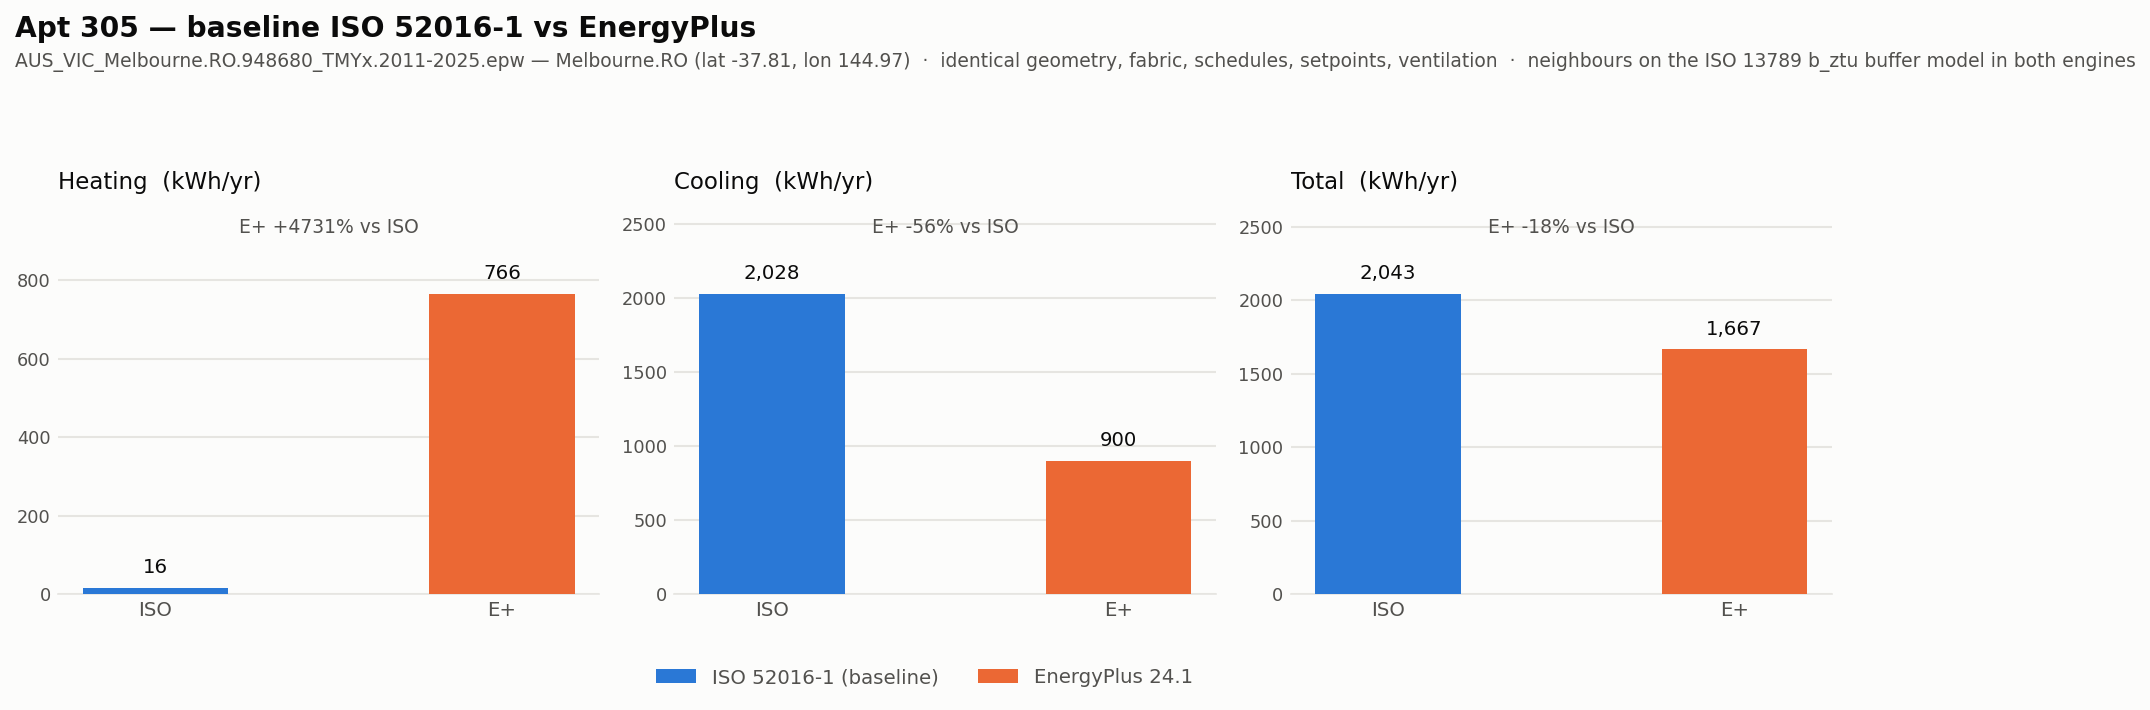

### pyBuildingEnergy annual energy balance (Sankey)

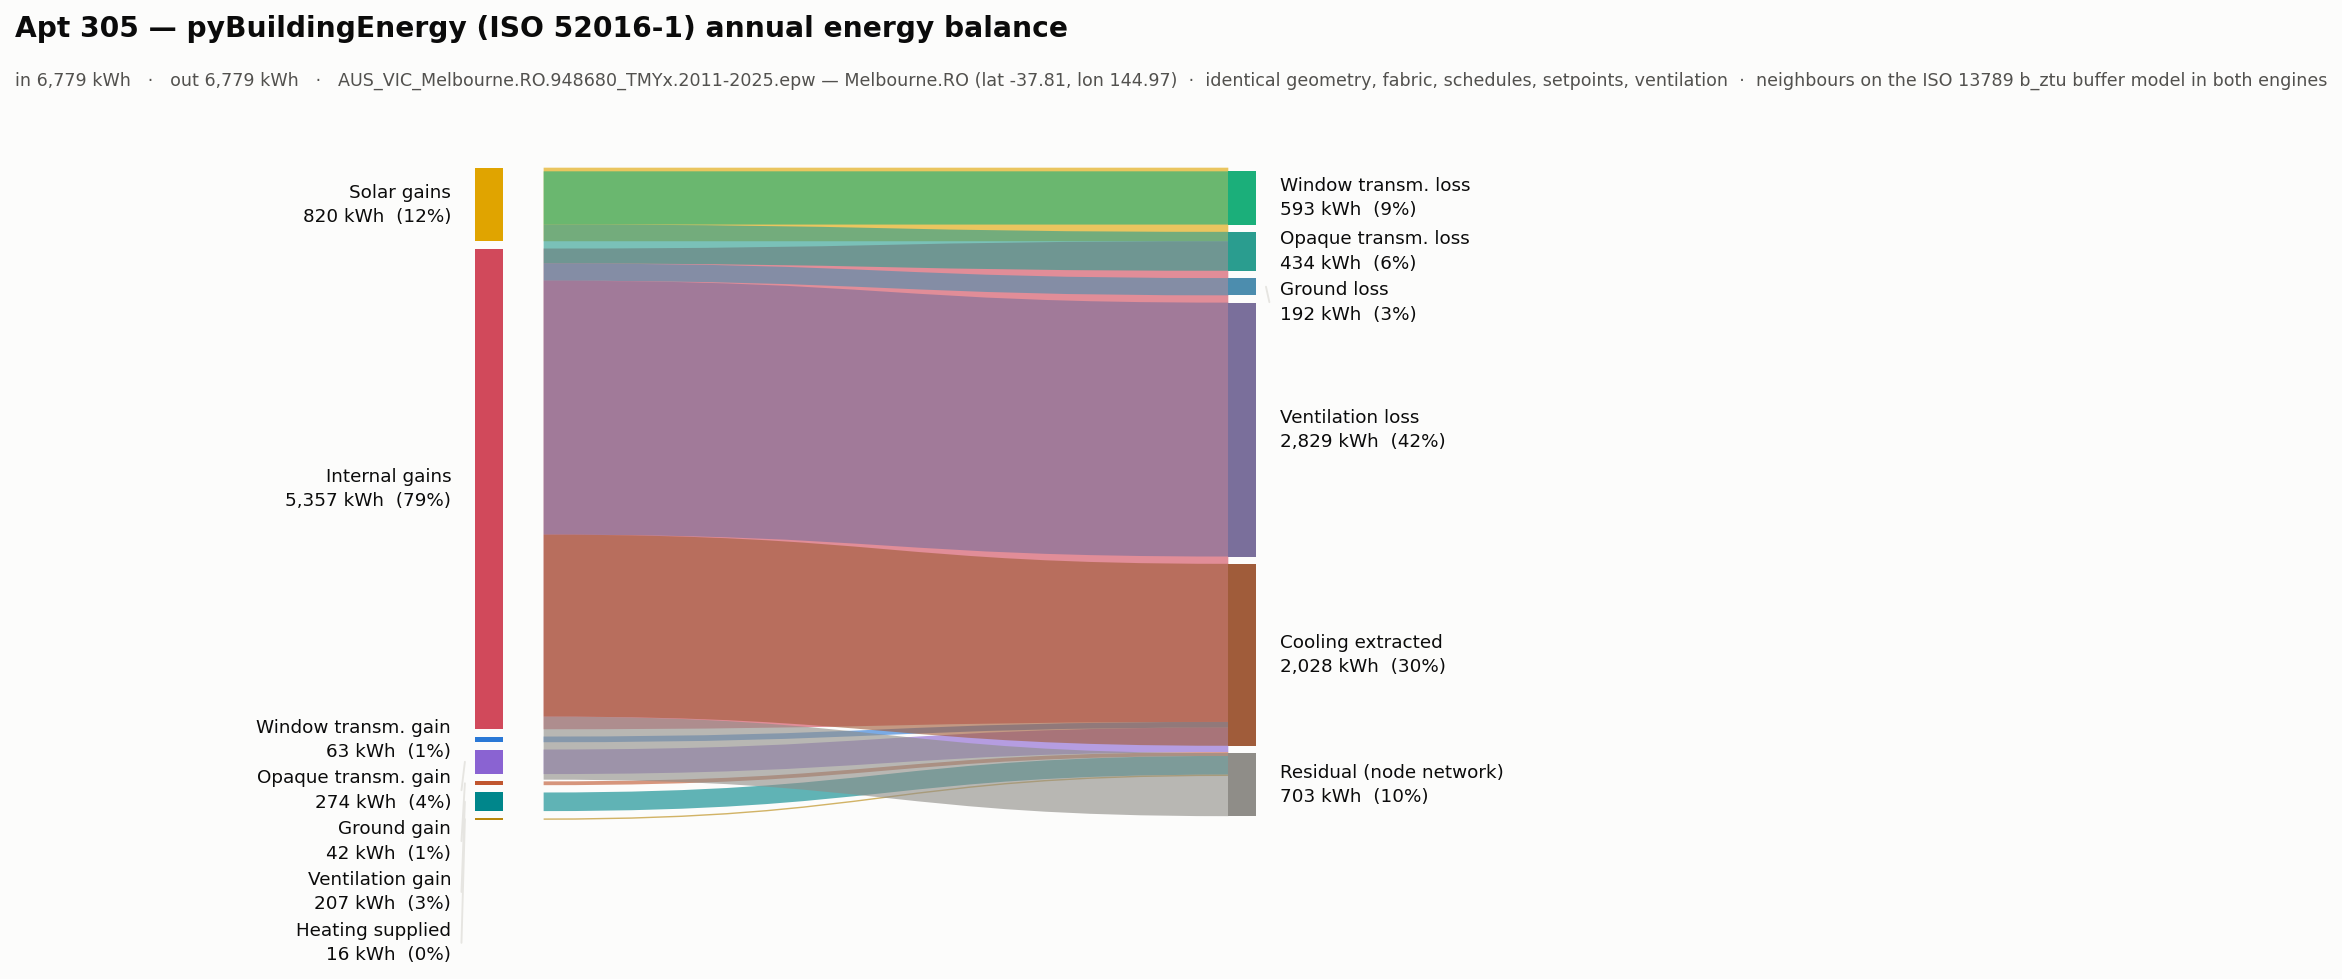

In [7]:
import pandas as pd
from IPython.display import Image, display, Markdown

display(Markdown("### Heating, cooling and total — ISO 52016-1 vs EnergyPlus"))
display(pd.read_csv("results/baseline_vs_ep/baseline_vs_energyplus.csv"))
display(Image("results/baseline_vs_ep/baseline_vs_energyplus.png"))

display(Markdown("### pyBuildingEnergy annual energy balance (Sankey)"))
display(Image("results/baseline_vs_ep/sankey_pybuildingenergy.png"))

In [8]:
import json, sys
sys.path.insert(0, "examples")
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"

from baseline_vs_energyplus import sankey_flows, SANKEY_IN_COLORS, SANKEY_OUT_COLORS

iso = json.load(open("results/baseline_vs_ep/iso_results.json"))
inflows, outflows = sankey_flows(iso)

labels = [n for n, _ in inflows] + ["Zone"] + [n for n, _ in outflows]
z = len(inflows)
colors = ([SANKEY_IN_COLORS[i] for i in range(len(inflows))] + ["#52514e"]
          + [SANKEY_OUT_COLORS[i] for i in range(len(outflows))])

fig = go.Figure(go.Sankey(
    node=dict(pad=18, thickness=18, label=labels, color=colors),
    link=dict(
        source=list(range(z)) + [z] * len(outflows),
        target=[z] * z + list(range(z + 1, len(labels))),
        value=[v for _, v in inflows] + [v for _, v in outflows],
        color=[colors[i] for i in range(z)]
              + [colors[z + 1 + i] for i in range(len(outflows))],
    ),
))
fig.update_layout(title="Apt 305 — ISO 52016-1 annual energy balance (kWh/yr)", height=560)
fig.show()

In [9]:
!python examples/compare_branches_apt305.py \
    --weather "$EPW" --require-epw --outdir results/apt305

resolving weather…
  -> AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw — Melbourne.RO (lat -37.81, lon 144.97)

running Baseline         (claude/pybuildingenergy-baseline-anjro8)
running + Window         (claude/dynamic-window-properties-anjro8)
running + Window + h_ce  (claude/window-plus-dynamic-hce-anjro8)

Metric                 Unit     Baseline     + Window  + Window + h_ce  C1 vs base   C2 vs C1  C2 vs base
---------------------------------------------------------------------------------------------------------
Heating need            kWh         15.9         13.9             14.1     -12.48%     +1.25%     -11.39%
Cooling need            kWh      2,027.5      2,029.3          2,253.3      +0.09%    +11.04%     +11.14%
Solar gains             kWh        819.6        718.2            718.2     -12.37%     +0.00%     -12.37%
Window transm. loss     kWh        593.1        527.0            527.1     -11.15%     +0.02%     -11.14%
Opaque transm. loss     kWh        433.6        441.

,Metric,Unit,Baseline,+ Window,+ Window + h_ce,C1 vs base %,C2 vs C1 %,C2 vs base %
0,Heating need,kWh,15.8616,13.8818,14.0555,-12.4816,1.2509,-11.3868
1,Cooling need,kWh,2027.5065,2029.3148,2253.3211,0.0892,11.0385,11.1376
2,Solar gains,kWh,819.5857,718.2273,718.2273,-12.3670,0.0000,-12.3670
3,Window transm. loss,kWh,593.1401,526.9954,527.0773,-11.1516,0.0155,-11.1378
4,Opaque transm. loss,kWh,433.5500,441.5087,439.5027,1.8357,-0.4544,1.3730
5,Total transm. loss,kWh,1005.1709,951.2714,946.8150,-5.3622,-0.4685,-5.8056


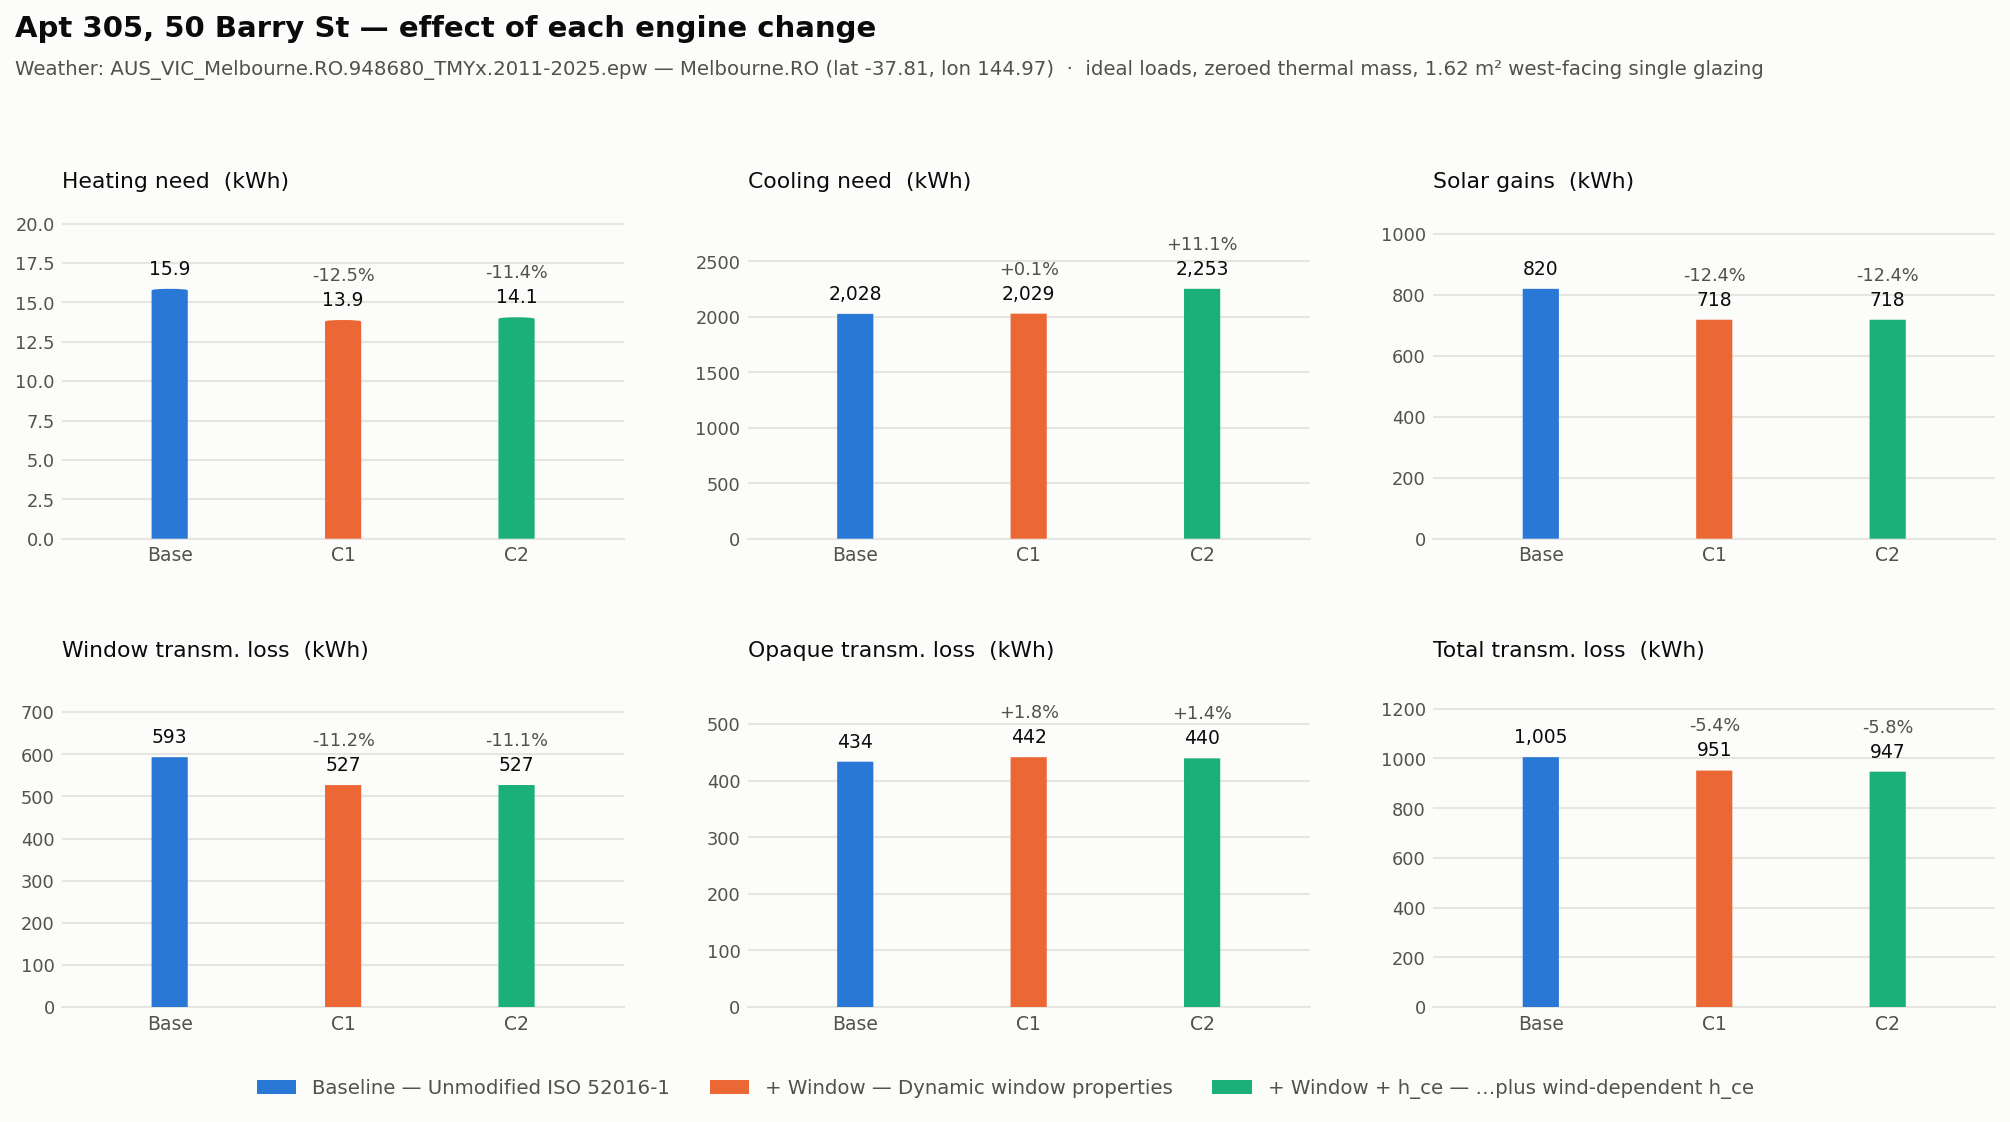

In [10]:
import pandas as pd
from IPython.display import Image, display

display(pd.read_csv("results/apt305/comparison.csv"))
display(Image("results/apt305/apt305_comparison.png"))

In [11]:
!python examples/compare_ventilation_latent.py \
    --weather "$EPW" --require-epw --outdir results/ventilation_latent

resolving weather…
  -> AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw — Melbourne.RO (lat -37.81, lon 144.97)

running Base   (claude/pybuildingenergy-baseline-anjro8)
running C1     (claude/ventilation-infiltration-fix)
running C2     (claude/latent-heat-fix)
running C3     (claude/ventilation-plus-latent-fix)

Metric                     Unit        Base          C1          C2          C3  C1 vs Base  C2 vs Base  C3 vs Base    C3 vs C1    C3 vs C2
-------------------------------------------------------------------------------------------------------------------------------------------
Heating need                kWh        15.9        37.3        15.9        37.3    +135.39%      +0.00%    +135.39%      +0.00%    +135.39%
Cooling need                kWh     2,027.5     1,727.2     2,027.5     1,727.2     -14.81%      +0.00%     -14.81%      +0.00%     -14.81%
Ventilation+infilt. loss    kWh     2,829.3     3,235.4     2,829.3     3,235.4     +14.36%      +0.00%     +14.36%      +0.0

,Metric,Unit,Base,C1,C2,C3,C1 vs Base %,C2 vs Base %,C3 vs Base %,C3 vs C1 %,C3 vs C2 %
0,Heating need,kWh,15.8616,37.3366,15.8616,37.3366,135.3894,0.0000,135.3894,0.0000,135.3894
1,Cooling need,kWh,2027.5065,1727.1773,2027.5065,1727.1773,-14.8127,0.0000,-14.8127,0.0000,-14.8127
2,Ventilation+infilt. loss,kWh,2829.2672,3235.4225,2829.2672,3235.4225,14.3555,0.0000,14.3555,0.0000,14.3555
3,Latent cooling need,kWh,301.2459,416.4272,290.8105,305.5422,38.2350,-3.4641,1.4262,-26.6277,5.0658
4,Latent heating need,kWh,1430.9732,1181.6508,1.0284,0.7742,-17.4233,-99.9281,-99.9459,-99.9345,-24.7221
5,Total energy need,kWh,3775.5872,3362.5918,2335.2070,2070.8302,-10.9386,-38.1498,-45.1521,-38.4157,-11.3213


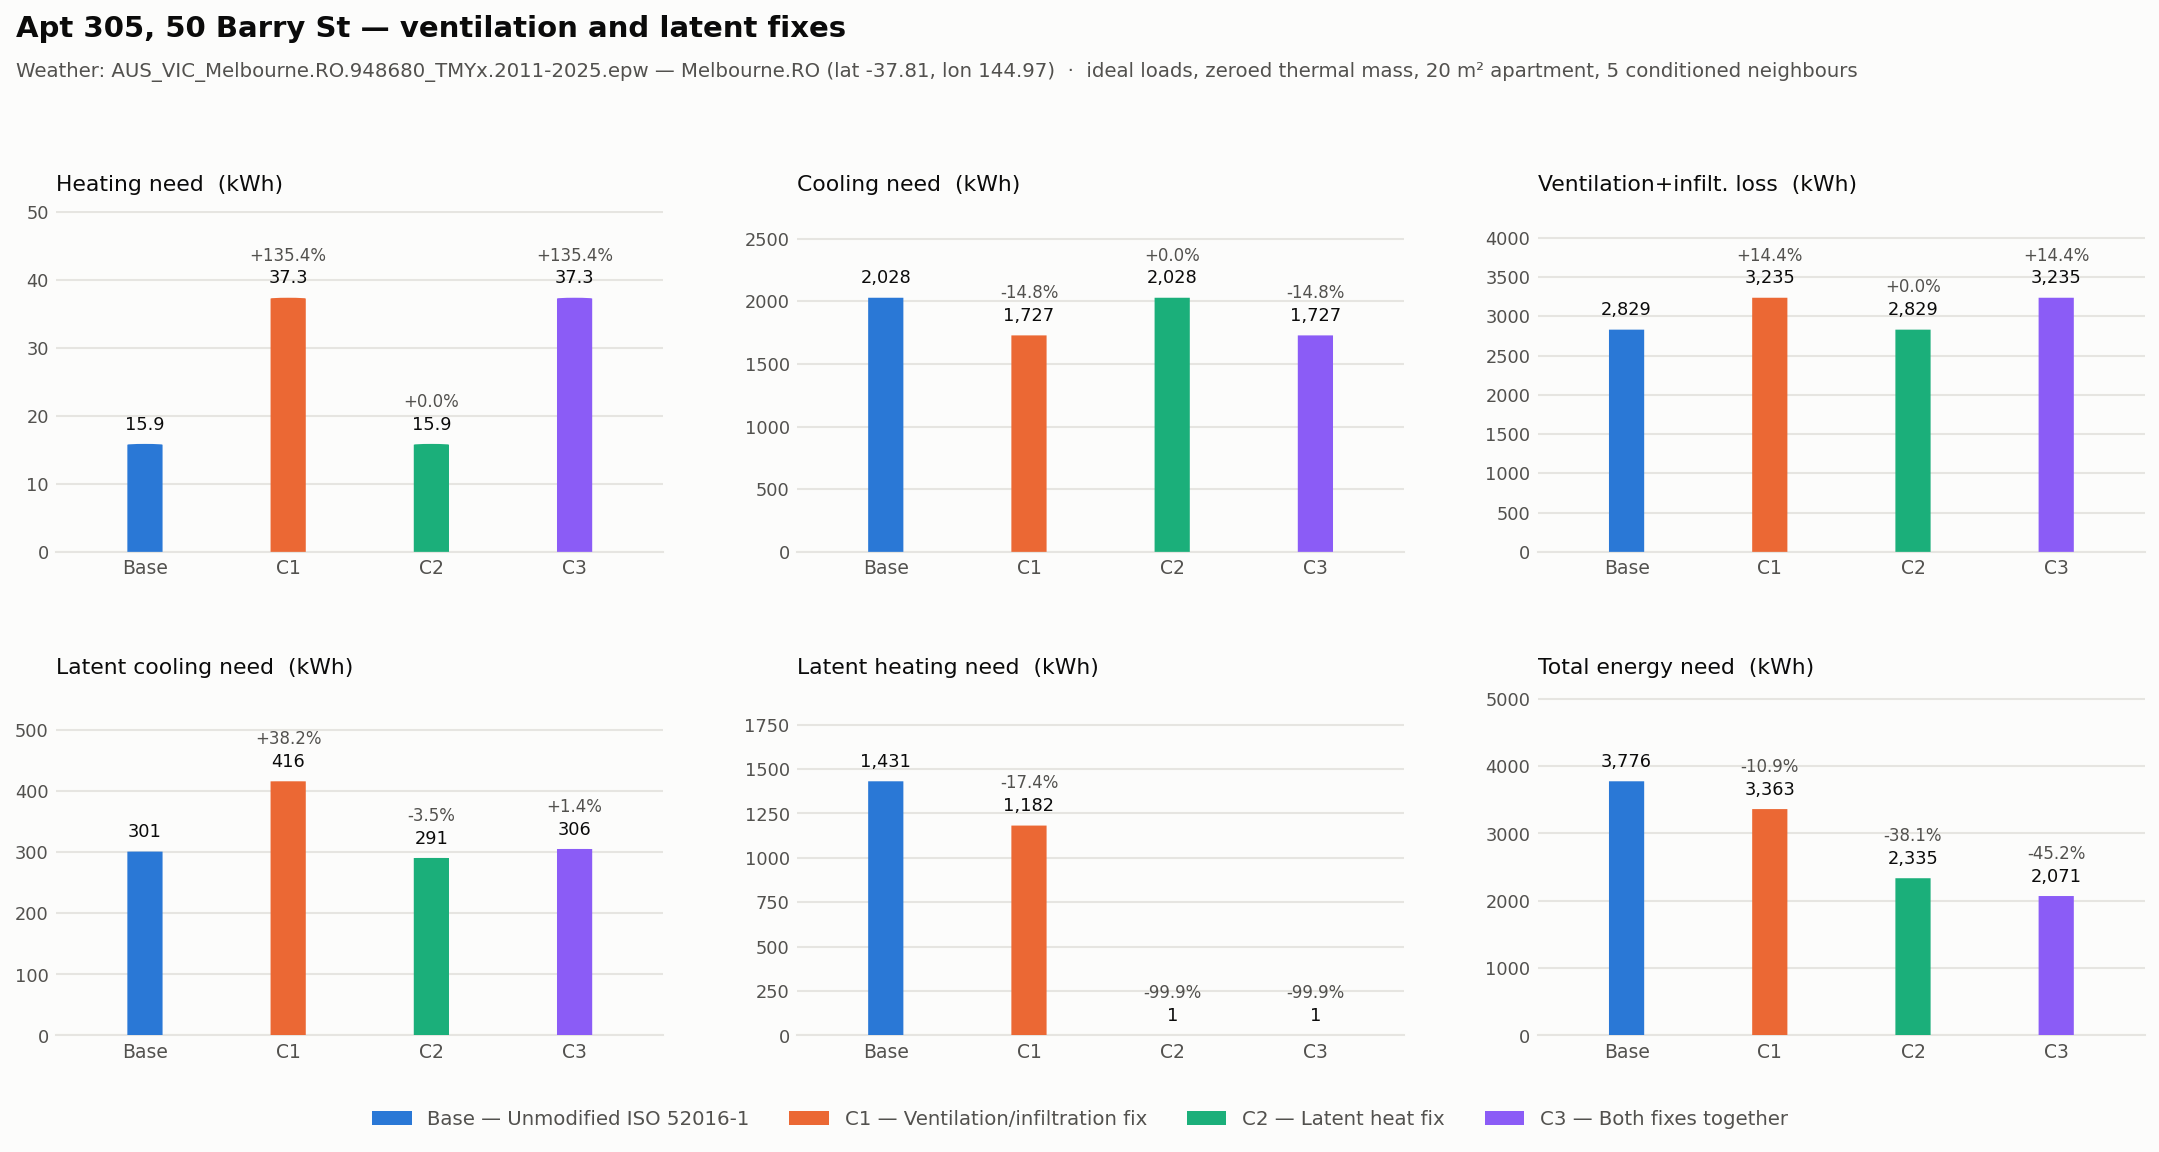

In [12]:
import pandas as pd
from IPython.display import Image, display

display(pd.read_csv("results/ventilation_latent/comparison.csv"))
display(Image("results/ventilation_latent/ventilation_latent_comparison.png"))

In [13]:
!python examples/check_baseline_consistency.py

weather actually used
  compare_branches      : AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw — Melbourne.RO (lat -37.81, lon 144.97)
  baseline_vs_energyplus: AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw — Melbourne.RO (lat -37.81, lon 144.97)

Metric          compare_branches    baseline_vs_EP     rel. diff
----------------------------------------------------------------
Heating                15.861617         15.861617      0.00e+00
Cooling             2,027.506478      2,027.506478      0.00e+00

PASS  both harnesses report the same baseline engine result.

